In [1]:
# Cell 1 - Load model
from tensorflow.keras.models import load_model

model = load_model("unet_1_augmented_fine2.h5", compile=False)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [2]:
# Cell 2 - Imports and settings
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, jaccard_score

IMG_SIZE    = 256
NUM_CLASSES = 3

In [3]:
# Cell 3 - Function to load images and masks
def load_data(image_dir, mask_dir):
    
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    mask_files  = sorted([f for f in os.listdir(mask_dir)  if f.endswith('.png')])
    
    X = []  # will store images
    Y = []  # will store masks
    
    for img_name, mask_name in zip(image_files, mask_files):
        
        # load and resize image
        img  = cv2.imread(os.path.join(image_dir, img_name))
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img  = img / 255.0  # normalize to 0-1
        
        # load and resize mask
        mask = cv2.imread(os.path.join(mask_dir, mask_name), 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        
        # convert grayscale mask to class labels (0, 1, 2)
        class_mask = np.zeros_like(mask, dtype=np.uint8)
        class_mask[(mask>=64) & (mask < 192)] = 1  # lithics
        class_mask[mask>=192]                 = 2  # clasts
        
        X.append(img)
        Y.append(to_categorical(class_mask, num_classes=NUM_CLASSES))
    
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.uint8)

In [4]:
# Cell 4 - List of all datasets to evaluate
all_datasets = [
    ('GF5.1',   'dataset51/images/',   'dataset51/masks/'),
    ('MAR01.1', 'dataset11/images/',   'dataset11/masks/'),
    ('MAR01.2', 'dataset12/images/',   'dataset12/masks/'),
    ('GF21',    'dataset21/images/',   'dataset21/masks/'),
    ('GF11',    'datasetgf11/images/', 'datasetgf11/masks/'),
    ('GF12',    'datasetgf12/images/', 'datasetgf12/masks/'),
]


 Evaluating: GF5.1 


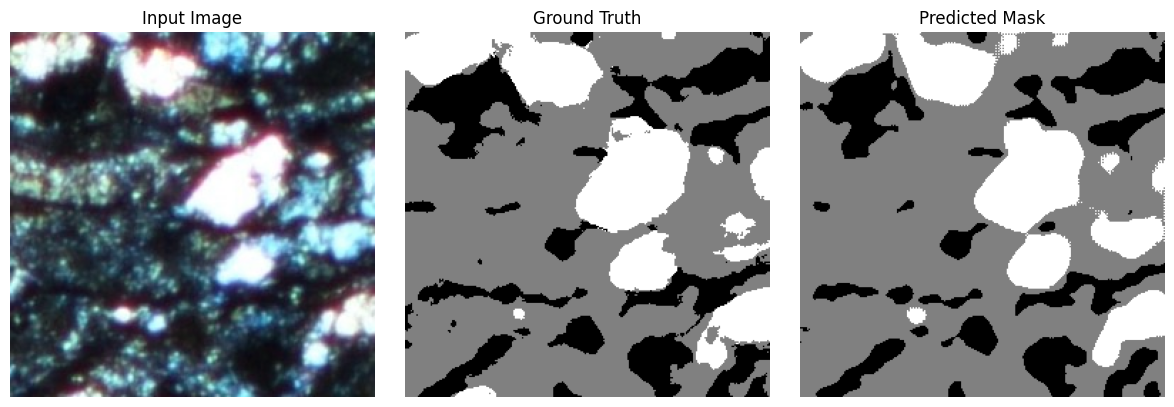

              precision    recall  f1-score   support

      Matrix       0.97      0.87      0.92    285387
      Clasts       0.94      0.96      0.95    766069
     Lithics       0.83      0.89      0.86    128192

    accuracy                           0.93   1179648
   macro avg       0.91      0.91      0.91   1179648
weighted avg       0.93      0.93      0.93   1179648

IoU per class: [0.8488707  0.90006613 0.75291693]

 Evaluating: MAR01.1 


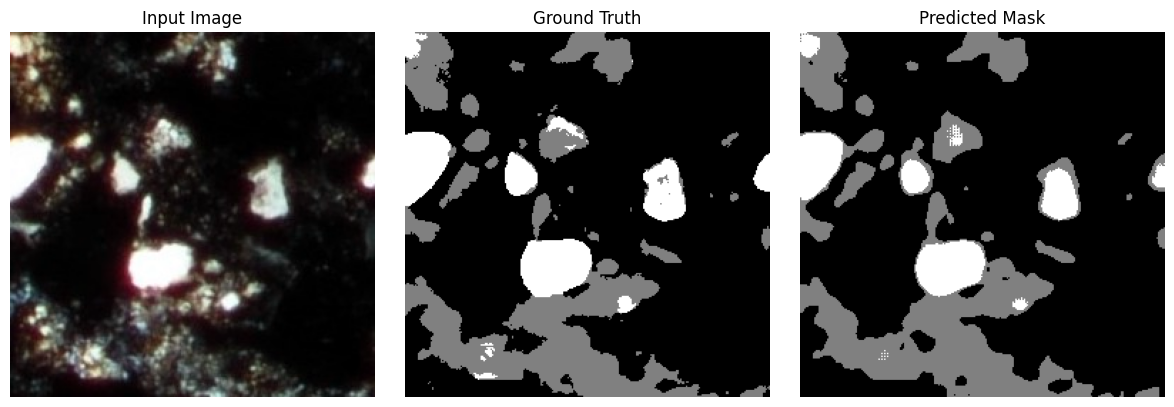

              precision    recall  f1-score   support

      Matrix       0.98      0.99      0.98    353173
      Clasts       0.88      0.92      0.90     81981
     Lithics       0.93      0.80      0.86     23598

    accuracy                           0.96    458752
   macro avg       0.93      0.90      0.91    458752
weighted avg       0.96      0.96      0.96    458752

IoU per class: [0.97028563 0.81806998 0.74772908]

 Evaluating: MAR01.2 


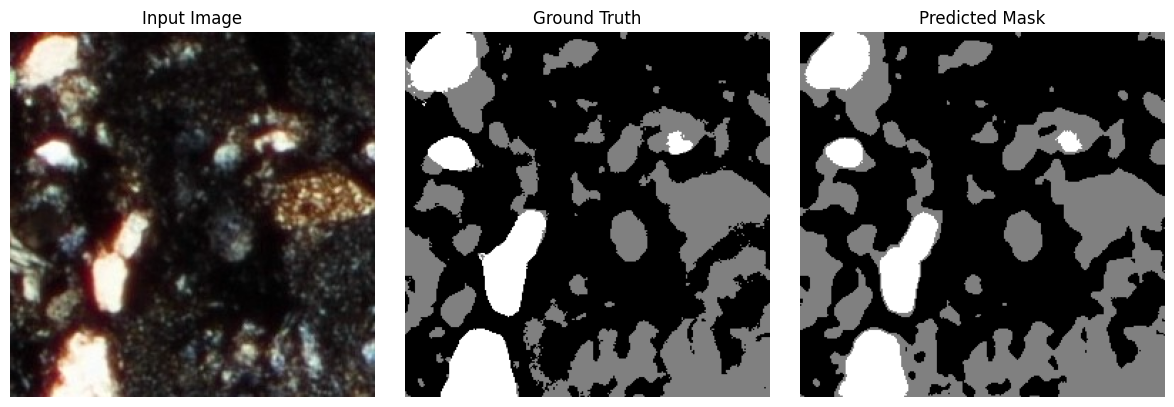

              precision    recall  f1-score   support

      Matrix       0.98      0.95      0.96    360064
      Clasts       0.89      0.94      0.92    224869
     Lithics       0.94      0.88      0.91     70427

    accuracy                           0.94    655360
   macro avg       0.94      0.93      0.93    655360
weighted avg       0.94      0.94      0.94    655360

IoU per class: [0.92847982 0.84674381 0.83428832]

 Evaluating: GF21 


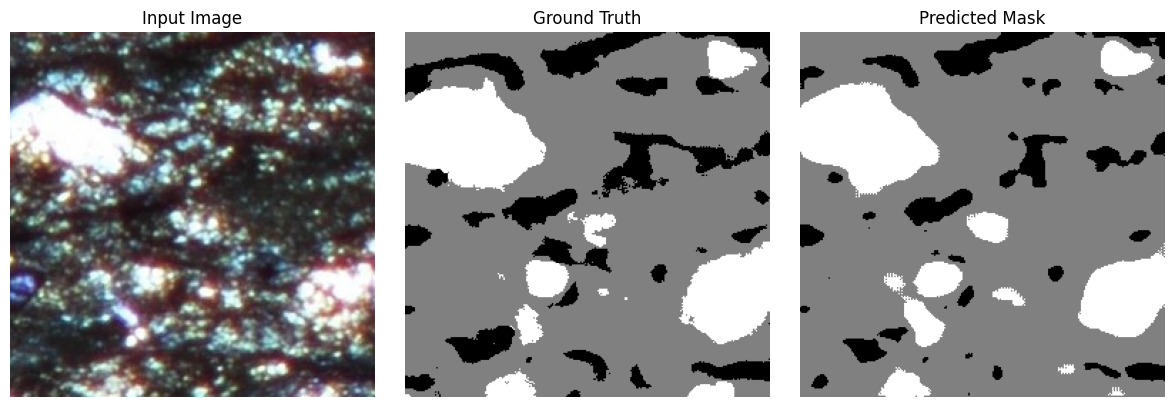

              precision    recall  f1-score   support

      Matrix       0.97      0.66      0.78     99157
      Clasts       0.88      0.97      0.92    443430
     Lithics       0.92      0.86      0.89    178309

    accuracy                           0.90    720896
   macro avg       0.92      0.83      0.87    720896
weighted avg       0.90      0.90      0.89    720896

IoU per class: [0.64491766 0.85355139 0.80351749]

 Evaluating: GF11 


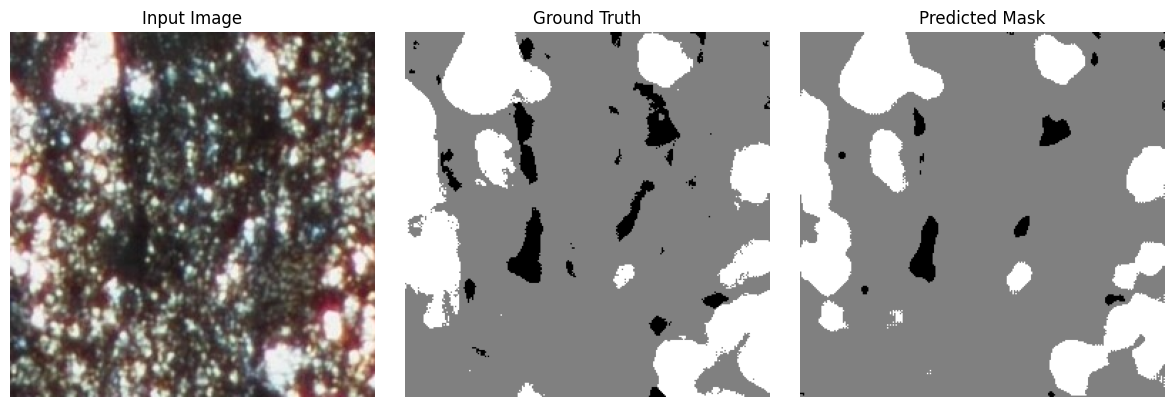

              precision    recall  f1-score   support

      Matrix       0.97      0.64      0.77     79240
      Clasts       0.92      0.99      0.95    498842
     Lithics       0.94      0.83      0.88     77278

    accuracy                           0.93    655360
   macro avg       0.94      0.82      0.87    655360
weighted avg       0.93      0.93      0.92    655360

IoU per class: [0.62212699 0.91190742 0.78922306]

 Evaluating: GF12 


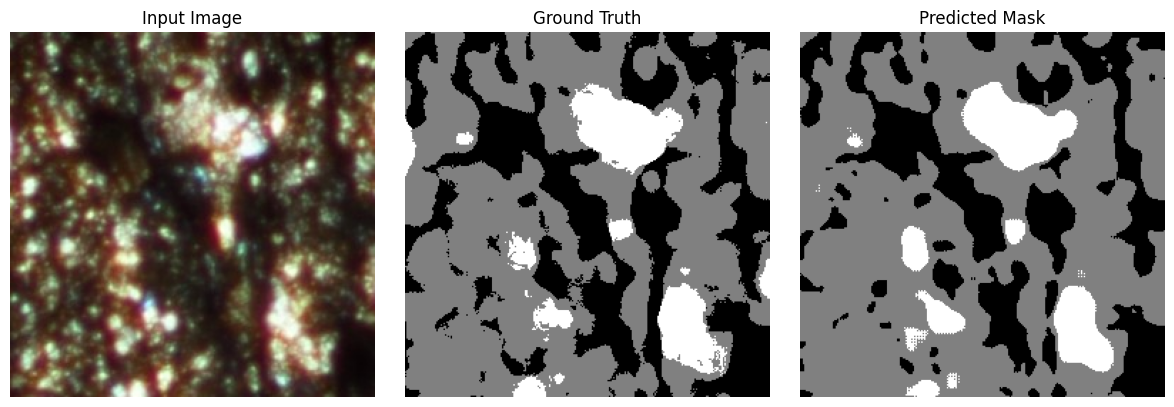

              precision    recall  f1-score   support

      Matrix       0.97      0.93      0.95    564400
      Clasts       0.89      0.95      0.92    481846
     Lithics       0.93      0.87      0.90    133402

    accuracy                           0.93   1179648
   macro avg       0.93      0.92      0.92   1179648
weighted avg       0.93      0.93      0.93   1179648

IoU per class: [0.90337717 0.84790117 0.81548026]


In [5]:
# Cell 5 - Run evaluation for each dataset one by one
for name, img_dir, mask_dir in all_datasets:
    
    print(f"\n Evaluating: {name} ")
    
    # load data
    X, Y = load_data(img_dir, mask_dir)
    
    # split into train and validation
    _, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
    
    # get predictions
    pred_probs   = model.predict(X_val, verbose=0)
    pred_classes = np.argmax(pred_probs,  axis=-1)
    true_classes = np.argmax(Y_val, axis=-1)
    
    # plot first sample
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 3, 1)
    plt.imshow(X_val[0])
    plt.title("Input Image")
    plt.axis('off')
    
    plt.subplot(1, 3, 2)
    plt.imshow(true_classes[0], cmap='gray')
    plt.title("Ground Truth")
    plt.axis('off')
    
    plt.subplot(1, 3, 3)
    plt.imshow(pred_classes[0], cmap='gray')
    plt.title("Predicted Mask")
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # print metrics
    print(classification_report(true_classes.flatten(), pred_classes.flatten(),
                                 target_names=["Matrix", "Clasts", "Lithics"]))
    
    print("IoU per class:", jaccard_score(true_classes.flatten(), pred_classes.flatten(), average=None))

In [6]:
# Cell 1 - Imports and settings
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, jaccard_score

IMG_SIZE    = 256
NUM_CLASSES = 3

In [7]:
# Cell 2 - List of all datasets
all_datasets = [
    ('GF5.1',   'dataset51/images/',   'dataset51/masks/'),
    ('MAR01.1', 'dataset11/images/',   'dataset11/masks/'),
    ('MAR01.2', 'dataset12/images/',   'dataset12/masks/'),
    ('GF21',    'dataset21/images/',   'dataset21/masks/'),
    ('GF11',    'datasetgf11/images/', 'datasetgf11/masks/'),
    ('GF12',    'datasetgf12/images/', 'datasetgf12/masks/'),
]

In [8]:
# Cell 3 - Function to load images and masks
def load_data(image_dir, mask_dir):
    
    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    mask_files  = sorted([f for f in os.listdir(mask_dir)  if f.endswith('.png')])
    
    X = []  # will store images
    Y = []  # will store masks
    
    for img_name, mask_name in zip(image_files, mask_files):
        
        # load and resize image
        img  = cv2.imread(os.path.join(image_dir, img_name))
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img  = img / 255.0  # normalize to 0-1
        
        # load and resize mask
        mask = cv2.imread(os.path.join(mask_dir, mask_name), 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)
        
        # convert grayscale mask to class labels (0, 1, 2)
        class_mask = np.zeros_like(mask, dtype=np.uint8)
        class_mask[(mask >= 64) & (mask < 192)] = 1  # lithics
        class_mask[mask >= 192]                 = 2  # clasts
        
        X.append(img)
        Y.append(to_categorical(class_mask, num_classes=NUM_CLASSES))
    
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.uint8)

In [9]:
# Cell 4 - Load both models
tf.keras.backend.clear_session()

unet = load_model('unet_1_augmented_fine2.h5', compile=False)
fcn  = load_model('fcn_model.h5',              compile=False)

unet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
fcn.compile( optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [10]:
# Cell 5 - Evaluate both models on all datasets
unet_f1s, unet_ious = [], []
fcn_f1s,  fcn_ious  = [], []

for name, img_dir, mask_dir in all_datasets:
    
    print(f"\n Evaluating: {name} ")
    
    # load data and split
    X, Y = load_data(img_dir, mask_dir)
    _, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)
    
    # get true labels
    true_cls = np.argmax(Y_val, axis=-1)
    
    # U-Net predictions
    unet_pred = np.argmax(unet.predict(X_val, verbose=0), axis=-1)
    unet_f1s.append( f1_score(     true_cls.flatten(), unet_pred.flatten(), average='macro'))
    unet_ious.append(jaccard_score(true_cls.flatten(), unet_pred.flatten(), average='macro'))
    
    # FCN predictions
    fcn_pred = np.argmax(fcn.predict(X_val, verbose=0), axis=-1)
    fcn_f1s.append( f1_score(     true_cls.flatten(), fcn_pred.flatten(), average='macro'))
    fcn_ious.append(jaccard_score(true_cls.flatten(), fcn_pred.flatten(), average='macro'))
    
    print(f"U-Net -> F1: {unet_f1s[-1]:.4f}, IoU: {unet_ious[-1]:.4f}")
    print(f"FCN -> F1: {fcn_f1s[-1]:.4f},  IoU: {fcn_ious[-1]:.4f}")


 Evaluating: GF5.1 
U-Net -> F1: 0.9082, IoU: 0.8340
FCN -> F1: 0.9066,  IoU: 0.8328

 Evaluating: MAR01.1 
U-Net -> F1: 0.9135, IoU: 0.8454
FCN -> F1: 0.8679,  IoU: 0.7745

 Evaluating: MAR01.2 
U-Net -> F1: 0.9299, IoU: 0.8698
FCN -> F1: 0.8836,  IoU: 0.7938

 Evaluating: GF21 
U-Net -> F1: 0.8654, IoU: 0.7673
FCN -> F1: 0.8655,  IoU: 0.7644

 Evaluating: GF11 
U-Net -> F1: 0.8677, IoU: 0.7744
FCN -> F1: 0.8560,  IoU: 0.7532

 Evaluating: GF12 
U-Net -> F1: 0.9218, IoU: 0.8556
FCN -> F1: 0.8696,  IoU: 0.7705


In [11]:
# Cell 6 - Print final mean scores
print("\nU-Net Mean F1:  ", round(np.mean(unet_f1s),  4))
print("U-Net Mean IoU: ", round(np.mean(unet_ious), 4))
print("\nFCN Mean F1:    ", round(np.mean(fcn_f1s),   4))
print("FCN Mean IoU:   ", round(np.mean(fcn_ious),  4))


U-Net Mean F1:   0.9011
U-Net Mean IoU:  0.8244

FCN Mean F1:     0.8749
FCN Mean IoU:    0.7815


In [12]:
# Cell 1 - Imports and settings
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, jaccard_score

IMG_SIZE    = 256
NUM_CLASSES = 3

In [13]:
# Cell 2 - List of all datasets
all_datasets = [
    ('GF5.1',   'dataset51/images/',   'dataset51/masks/'),
    ('MAR01.1', 'dataset11/images/',   'dataset11/masks/'),
    ('MAR01.2', 'dataset12/images/',   'dataset12/masks/'),
    ('GF21',    'dataset21/images/',   'dataset21/masks/'),
    ('GF11',    'datasetgf11/images/', 'datasetgf11/masks/'),
    ('GF12',    'datasetgf12/images/', 'datasetgf12/masks/'),
]

In [14]:
# Cell 3 - Function to load images and masks
def load_data(image_dir, mask_dir):

    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    mask_files  = sorted([f for f in os.listdir(mask_dir)  if f.endswith('.png')])

    X = []  # will store images
    Y = []  # will store masks

    for img_name, mask_name in zip(image_files, mask_files):

        # load and resize image
        img  = cv2.imread(os.path.join(image_dir, img_name))
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img  = img / 255.0  # normalize to 0-1

        # load and resize mask
        mask = cv2.imread(os.path.join(mask_dir, mask_name), 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # convert grayscale mask to class labels (0, 1, 2)
        class_mask = np.zeros_like(mask, dtype=np.uint8)
        class_mask[(mask >= 64) & (mask < 192)] = 1  # lithics
        class_mask[mask >= 192]                 = 2  # clasts

        X.append(img)
        Y.append(to_categorical(class_mask, num_classes=NUM_CLASSES))

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.uint8)

In [15]:
# Cell 4 - Load both models
tf.keras.backend.clear_session()

unet = load_model('unet_1_augmented_fine2.h5', compile=False)
fcn  = load_model('fcn_model.h5',              compile=False)

unet.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
fcn.compile( optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [16]:
# Cell 5 - Evaluate both models on all datasets
unet_f1s,  unet_ious  = [], []
fcn_f1s,   fcn_ious   = [], []

for name, img_dir, mask_dir in all_datasets:

    print(f"\n- Evaluating: {name}")

    # load data and split into train/val
    X, Y = load_data(img_dir, mask_dir)
    _, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

    # get true class labels
    true_cls = np.argmax(Y_val, axis=-1)

    # u-net predictions
    unet_pred = np.argmax(unet.predict(X_val, verbose=0), axis=-1)
    unet_f1s.append( f1_score(     true_cls.flatten(), unet_pred.flatten(), average='macro'))
    unet_ious.append(jaccard_score(true_cls.flatten(), unet_pred.flatten(), average='macro'))

    # fcn predictions
    fcn_pred = np.argmax(fcn.predict(X_val, verbose=0), axis=-1)
    fcn_f1s.append( f1_score( true_cls.flatten(), fcn_pred.flatten(), average='macro'))
    fcn_ious.append(jaccard_score(true_cls.flatten(), fcn_pred.flatten(), average='macro'))

    print(f"U-Net -> F1: {unet_f1s[-1]:.4f}, IoU: {unet_ious[-1]:.4f}")
    print(f"FCN -> F1: {fcn_f1s[-1]:.4f},  IoU: {fcn_ious[-1]:.4f}")


- Evaluating: GF5.1
U-Net -> F1: 0.9082, IoU: 0.8340
FCN -> F1: 0.9066,  IoU: 0.8328

- Evaluating: MAR01.1
U-Net -> F1: 0.9135, IoU: 0.8454
FCN -> F1: 0.8679,  IoU: 0.7745

- Evaluating: MAR01.2
U-Net -> F1: 0.9299, IoU: 0.8698
FCN -> F1: 0.8836,  IoU: 0.7938

- Evaluating: GF21
U-Net -> F1: 0.8654, IoU: 0.7673
FCN -> F1: 0.8655,  IoU: 0.7644

- Evaluating: GF11
U-Net -> F1: 0.8677, IoU: 0.7744
FCN -> F1: 0.8560,  IoU: 0.7532

- Evaluating: GF12
U-Net -> F1: 0.9218, IoU: 0.8556
FCN -> F1: 0.8696,  IoU: 0.7705


In [17]:
# Cell 6 - Print final mean scores
print("\nU-Net Mean F1:", round(np.mean(unet_f1s),  4))
print("U-Net Mean IoU:", round(np.mean(unet_ious), 4))

print("\nFCN Mean F1:", round(np.mean(fcn_f1s),  4))
print("FCN Mean IoU:", round(np.mean(fcn_ious), 4))


U-Net Mean F1: 0.9011
U-Net Mean IoU: 0.8244

FCN Mean F1: 0.8749
FCN Mean IoU: 0.7815


In [18]:
# Cell 1 - Imports and settings
import os
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, jaccard_score

IMG_SIZE    = 256
NUM_CLASSES = 3

In [19]:
# Cell 2 - List of all datasets
all_datasets = [
    ('GF5.1',   'dataset51/images/',   'dataset51/masks/'),
    ('MAR01.1', 'dataset11/images/',   'dataset11/masks/'),
    ('MAR01.2', 'dataset12/images/',   'dataset12/masks/'),
    ('GF21',    'dataset21/images/',   'dataset21/masks/'),
    ('GF11',    'datasetgf11/images/', 'datasetgf11/masks/'),
    ('GF12',    'datasetgf12/images/', 'datasetgf12/masks/'),
]

In [20]:
# Cell 3 - Function to load images and masks
def load_data(image_dir, mask_dir):

    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    mask_files  = sorted([f for f in os.listdir(mask_dir)  if f.endswith('.png')])

    X = []  # will store images
    Y = []  # will store masks

    for img_name, mask_name in zip(image_files, mask_files):

        # load and resize image
        img  = cv2.imread(os.path.join(image_dir, img_name))
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img  = img / 255.0  # normalize to 0-1

        # load and resize mask
        mask = cv2.imread(os.path.join(mask_dir, mask_name), 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # convert grayscale mask to class labels (0, 1, 2)
        class_mask = np.zeros_like(mask, dtype=np.uint8)
        class_mask[(mask >= 64) & (mask < 192)] = 1  # lithics
        class_mask[mask >= 192]                 = 2  # clasts

        X.append(img)
        Y.append(to_categorical(class_mask, num_classes=NUM_CLASSES))

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.uint8)

In [21]:
# Cell 4 - Load U-Net without augmentation model
tf.keras.backend.clear_session()

unet_noaug = load_model('unet_noaug.h5', compile=False)
unet_noaug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [22]:
# Cell 5 - Evaluate on all datasets
f1s  = []
ious = []

for name, img_dir, mask_dir in all_datasets:

    print(f"\n Evaluating: {name} ")

    # load data and split
    X, Y = load_data(img_dir, mask_dir)
    _, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

    # get true and predicted labels
    true_cls = np.argmax(Y_val,                              axis=-1)
    pred_cls = np.argmax(unet_noaug.predict(X_val, verbose=0), axis=-1)

    # calculate metrics
    f1  = f1_score( true_cls.flatten(), pred_cls.flatten(), average='macro')
    iou = jaccard_score(true_cls.flatten(), pred_cls.flatten(), average='macro')

    f1s.append(f1)
    ious.append(iou)

    print(f"F1: {f1:.4f}, IoU: {iou:.4f}")


 Evaluating: GF5.1 
F1: 0.9194, IoU: 0.8517

 Evaluating: MAR01.1 
F1: 0.8996, IoU: 0.8222

 Evaluating: MAR01.2 
F1: 0.9109, IoU: 0.8380

 Evaluating: GF21 
F1: 0.9111, IoU: 0.8379

 Evaluating: GF11 
F1: 0.8994, IoU: 0.8211

 Evaluating: GF12 
F1: 0.8653, IoU: 0.7656


In [23]:
# Cell 6 - Print final mean scores
print("\nU-Net (no augmentation) Mean F1:  ", round(np.mean(f1s),  4))
print("U-Net (no augmentation) Mean IoU: ", round(np.mean(ious), 4))


U-Net (no augmentation) Mean F1:   0.9009
U-Net (no augmentation) Mean IoU:  0.8228


In [24]:
# Cell 1 - Imports and settings
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, jaccard_score
from sklearn.ensemble import RandomForestClassifier

IMG_SIZE    = 256
NUM_CLASSES = 3

In [25]:
# Cell 2 - List of all datasets
all_datasets = [
    ('GF5.1',   'dataset51/images/',   'dataset51/masks/'),
    ('MAR01.1', 'dataset11/images/',   'dataset11/masks/'),
    ('MAR01.2', 'dataset12/images/',   'dataset12/masks/'),
    ('GF21',    'dataset21/images/',   'dataset21/masks/'),
    ('GF11',    'datasetgf11/images/', 'datasetgf11/masks/'),
    ('GF12',    'datasetgf12/images/', 'datasetgf12/masks/'),
]

In [26]:
# Cell 3 - Function to load images and masks
def load_data(image_dir, mask_dir):

    image_files = sorted([f for f in os.listdir(image_dir) if f.endswith('.png')])
    mask_files  = sorted([f for f in os.listdir(mask_dir)  if f.endswith('.png')])

    X = []  # will store images
    Y = []  # will store masks

    for img_name, mask_name in zip(image_files, mask_files):

        # load and resize image
        img  = cv2.imread(os.path.join(image_dir, img_name))
        img  = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img  = img / 255.0  # normalize to 0-1

        # load and resize mask
        mask = cv2.imread(os.path.join(mask_dir, mask_name), 0)
        mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        # convert grayscale mask to class labels (0, 1, 2)
        class_mask = np.zeros_like(mask, dtype=np.uint8)
        class_mask[(mask >= 64) & (mask < 192)] = 1  # lithics
        class_mask[mask >= 192]                 = 2  # clasts

        X.append(img)
        Y.append(to_categorical(class_mask, num_classes=NUM_CLASSES))

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.uint8)

In [27]:
# Cell 4 - Otsu prediction function
def otsu_predict(X_val):

    preds = []

    for img in X_val:

        # convert to grayscale
        gray = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_BGR2GRAY)

        # assign class labels based on intensity
        mask = np.zeros_like(gray, dtype=np.uint8)
        mask[(gray>= 64) & (gray < 192)] = 1  # lithics
        mask[gray>= 192]                  = 2  # clasts

        preds.append(mask)

    return np.array(preds)

In [28]:
# Cell 5 - Evaluate Random Forest and Otsu on all datasets
rf_f1s,   rf_ious   = [], []
otsu_f1s, otsu_ious = [], []

for name, img_dir, mask_dir in all_datasets:

    print(f"\n Evaluating: {name} ")

    # load data and split
    X, Y = load_data(img_dir, mask_dir)
    _, X_val, _, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

    # get true labels
    true_cls = np.argmax(Y_val, axis=-1)

    # random forest - train and predict
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_val.reshape(-1, 3), true_cls.flatten())
    rf_pred = rf.predict(X_val.reshape(-1, 3)).reshape(X_val.shape[0], IMG_SIZE, IMG_SIZE)

    rf_f1s.append( f1_score(     true_cls.flatten(), rf_pred.flatten(), average='macro'))
    rf_ious.append(jaccard_score(true_cls.flatten(), rf_pred.flatten(), average='macro'))

    print(f"Random Forest -> F1: {rf_f1s[-1]:.4f}, IoU: {rf_ious[-1]:.4f}")

    # otsu - predict only
    otsu_pred = otsu_predict(X_val)

    otsu_f1s.append( f1_score( true_cls.flatten(), otsu_pred.flatten(), average='macro'))
    otsu_ious.append(jaccard_score(true_cls.flatten(), otsu_pred.flatten(), average='macro'))

    print(f"Otsu -> F1: {otsu_f1s[-1]:.4f}, IoU: {otsu_ious[-1]:.4f}")


 Evaluating: GF5.1 
Random Forest -> F1: 0.9169, IoU: 0.8474
Otsu -> F1: 0.6592, IoU: 0.4919

 Evaluating: MAR01.1 
Random Forest -> F1: 0.9375, IoU: 0.8846
Otsu -> F1: 0.7462, IoU: 0.6178

 Evaluating: MAR01.2 
Random Forest -> F1: 0.9113, IoU: 0.8380
Otsu -> F1: 0.7038, IoU: 0.5556

 Evaluating: GF21 
Random Forest -> F1: 0.8596, IoU: 0.7567
Otsu -> F1: 0.5986, IoU: 0.4287

 Evaluating: GF11 
Random Forest -> F1: 0.8426, IoU: 0.7369
Otsu -> F1: 0.5213, IoU: 0.3580

 Evaluating: GF12 
Random Forest -> F1: 0.9204, IoU: 0.8529
Otsu -> F1: 0.6664, IoU: 0.5096


In [29]:
# Cell 6 - Print final mean scores
print("\nRandom Forest Mean F1:  ", round(np.mean(rf_f1s),   4))
print("Random Forest Mean IoU: ", round(np.mean(rf_ious),  4))

print("\nOtsu Mean F1: ", round(np.mean(otsu_f1s), 4))
print("Otsu Mean IoU: ", round(np.mean(otsu_ious), 4))


Random Forest Mean F1:   0.8981
Random Forest Mean IoU:  0.8194

Otsu Mean F1:  0.6493
Otsu Mean IoU:  0.4936
